## 1. 환경 설정

`(1) Env 환경변수`

In [14]:
from dotenv import load_dotenv
load_dotenv()

True

## 2. prepare_context
- 학생 프로필 정보 (목표 대학, 계열)
- 최근 대화 내역 (학생 ↔ 선생님 대화 로그 일부)

두 가지를 받아서 질문 분석(analyze_question) 단계에 넘길 “맥락 포함 질문”을 생성

In [15]:
from typing import TypedDict, List, Dict

# LangGraph 상태 구조 정의
class QAState(TypedDict):
    question: str
    student_profile: Dict[str, str]
    recent_dialogues: List[Dict[str, str]]
    context: str
    category: str
    faq_answer: str
    search_results: List[Dict]
    candidate_answer: str
    evaluation: str
    final_answer: str
    sources: List[str]


In [16]:
def prepare_context(state: QAState) -> QAState:
    """
    학생 프로필과 최근 대화 내역을 종합하여 context 생성
    """
    # 학생 프로필 불러오기
    profile = state.get("student_profile", {})
    target_uni = profile.get("target_university", "미지정")
    track = profile.get("track", "계열 미지정")

    # 최근 대화 내역 가져오기 (학생과 선생님 5개 정도)
    dialogues = state.get("recent_dialogues", [])
    dialogue_summary = " ".join(
        [f"{d['role']}: {d['message']}" for d in dialogues[-5:]]
    )

    # 질문과 맥락 결합
    state["context"] = (
        f"[학생 프로필] 목표 대학: {target_uni}, 계열: {track}\n"
        f"[최근 대화 요약] {dialogue_summary}\n"
        f"[학생 질문] {state['question']}"
    )

    return state


In [17]:
# 초기 상태 정의
init_state: QAState = {
    "question": "혹시 중앙대학교 이과는 어떤 과목을 준비해야 하나요?",
    "student_profile": {
        "target_university": "중앙대학교",
        "track": "이과"
    },
    "recent_dialogues": [
        {"role": "student", "message": "아직 편입 공부를 시작하진 않았습니다."},
        {"role": "teacher", "message": "언제부터 공부 시작할 계획인가요?"},
        {"role": "student", "message": "다음 주부터 시작할 생각인데 정해지면 이야기해드릴게요."},
        {"role": "teacher", "message": "네 알겠습니다."},
        {"role": "student", "message": "혹시 중앙대학교 이과는 어떤 과목을 준비해야 하나요?"}
    ],
    "context": "",
    "category": "",
    "faq_answer": "",
    "search_results": [],
    "candidate_answer": "",
    "evaluation": "",
    "final_answer": "",
    "sources": []
}

# prepare_context 실행
updated_state = prepare_context(init_state)

print("=== 준비된 Context ===")
print(updated_state["context"])


=== 준비된 Context ===
[학생 프로필] 목표 대학: 중앙대학교, 계열: 이과
[최근 대화 요약] student: 아직 편입 공부를 시작하진 않았습니다. teacher: 언제부터 공부 시작할 계획인가요? student: 다음 주부터 시작할 생각인데 정해지면 이야기해드릴게요. teacher: 네 알겠습니다. student: 혹시 중앙대학교 이과는 어떤 과목을 준비해야 하나요?
[학생 질문] 혹시 중앙대학교 이과는 어떤 과목을 준비해야 하나요?


### 도구 1. Guideline_search
- 가이드라인DB 내에서 검색
### 도구 2. web_search
- 웹 검색 

In [18]:
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.retrievers import TavilySearchAPIRetriever
from langchain_core.tools import tool
from typing import List
import pandas as pd
import os


# ======================================================
# 1️⃣ Ollama Embeddings 초기화
# ======================================================
# - 반드시 터미널에서 아래 명령으로 모델 받아야 함:
#   ollama pull bge-m3
print("🚀 Ollama Embeddings 모델 초기화 중...")
embeddings_model = OllamaEmbeddings(model="bge-m3")


# ======================================================
# 2️⃣ Chroma DB 생성 또는 불러오기
# ======================================================
persist_dir = "./chroma_guideline"
collection_name = "guideline_db"

if not os.path.exists(persist_dir):
    print("📌 최초 실행: CSV에서 GuidelineDB 생성 중...")
    df = pd.read_csv("GuidelineDB.csv", encoding="utf-8")

    # CSV를 Document 리스트로 변환
    documents = []
    for _, row in df.iterrows():
        documents.append(
            Document(
                page_content=row["question"],
                metadata={
                    "answer": row["answer"],
                    "category": row.get("category", ""),
                    "source": "guidelineDB",
                    "source_name": "GuidelineDB",
                    "source_detail": row.get("출처", "출처 미기재"),
                }
            )
        )

    # 한 번에 DB 생성 및 저장
    guideline_db = Chroma.from_documents(
        documents=documents,
        embedding=embeddings_model,
        collection_name=collection_name,
        persist_directory=persist_dir
    )
    print("✅ GuidelineDB 생성 완료 (Chroma persisted).")
else:
    print("📌 기존 GuidelineDB 불러오는 중...")
    guideline_db = Chroma(
        collection_name=collection_name,
        persist_directory=persist_dir,
        embedding_function=embeddings_model
    )
    print("✅ GuidelineDB 로드 완료.")


# ======================================================
# 3️⃣ Re-rank 모델 설정
# ======================================================
print("🧠 Reranker 모델 로드 중 (BAAI/bge-reranker-v2-m3)...")
rerank_model = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3")
cross_reranker = CrossEncoderReranker(model=rerank_model, top_n=2)

guideline_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker,
    base_retriever=guideline_db.as_retriever(search_kwargs={"k": 2}),
)
print("✅ Reranker 및 Guideline Retriever 설정 완료.")


# ======================================================
# 4️⃣ GuidelineDB 검색 도구
# ======================================================
@tool
def guideline_search(query: str) -> List[Document]:
    """
    GuidelineDB에서 검색합니다.
    (질문-답변-출처를 함께 포함하여 반환)
    """
    print(f"\n🔍 [GuidelineDB Search] 쿼리: {query}")
    docs = guideline_retriever.invoke(query)
    formatted_docs = []

    if len(docs) == 0:
        print("❗ GuidelineDB에서 결과를 찾을 수 없습니다.")
        return [Document(page_content="관련 정보를 찾을 수 없습니다.", metadata={"source": "guidelineDB"})]

    print(f"📄 검색 결과 문서 수: {len(docs)}")

    for i, d in enumerate(docs):
        q = d.page_content.strip()
        a = d.metadata.get("answer", "").strip()
        src_detail = d.metadata.get("source_detail", "출처 미기재")

        print(f"   ▶ [{i+1}] {q[:50]}... (출처: {src_detail})")

        formatted_docs.append(
            Document(
                page_content=f"Q: {q}\nA: {a}",
                metadata={
                    "source": "guidelineDB",
                    "source_name": "GuidelineDB",
                    "source_detail": src_detail
                }
            )
        )

    print("✅ Guideline 검색 결과 포맷 완료.")
    return formatted_docs


# ======================================================
# 5️⃣ 웹 검색 도구
# ======================================================
print("🌐 Tavily Web Search Retriever 초기화 중...")
web_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker,
    base_retriever=TavilySearchAPIRetriever(k=10),
)
print("✅ Web Retriever 준비 완료.")


@tool
def web_search(query: str) -> List[Document]:
    """
    데이터베이스에 없는 정보 또는 최신 정보를 웹에서 검색합니다.
    (검색된 문서의 제목, URL, 내용 요약, 출처를 포함하여 반환)
    """
    print(f"\n🌐 [Web Search] 쿼리 실행: {query}")
    docs = web_retriever.invoke(query)
    formatted_docs = []

    if len(docs) == 0:
        print("❗ 웹 검색 결과 없음")
        return [Document(page_content="관련 정보를 찾을 수 없습니다.", metadata={"source": "web search"})]

    print(f"📄 검색된 문서 수: {len(docs)}")

    for i, doc in enumerate(docs):
        # 안전하게 URL과 제목 추출
        source_url = doc.metadata.get("source", "URL 미기재")
        title = doc.metadata.get("title", "제목 없음")
        snippet = doc.page_content[:400]

        print(f"   [{i+1}] {title}")
        print(f"       ↳ URL: {source_url}")

        formatted_docs.append(
            Document(
                page_content=(
                    f"🔹 제목: {title}\n"
                    f"🔗 출처 URL: {source_url}\n"
                    f"📄 내용 요약: {snippet}"
                ),
                metadata={
                    "source": "web search",
                    "source_name": title,
                    "source_url": source_url,
                    "source_detail": source_url
                }
            )
        )

    print(f"✅ 웹 검색 결과 {len(formatted_docs)}개 포맷 완료.")
    return formatted_docs


🚀 Ollama Embeddings 모델 초기화 중...
📌 기존 GuidelineDB 불러오는 중...
✅ GuidelineDB 로드 완료.
🧠 Reranker 모델 로드 중 (BAAI/bge-reranker-v2-m3)...
✅ Reranker 및 Guideline Retriever 설정 완료.
🌐 Tavily Web Search Retriever 초기화 중...
✅ Web Retriever 준비 완료.


In [19]:
# --------------------------
# 6. 테스트 실행
# --------------------------
if __name__ == "__main__":
    query = "중앙대학교 이과 편입은 어떤 과목을 준비해야 하나요?"
    results = guideline_search.invoke(query)

    print("\n=== 검색 결과 ===")
    for r in results:
        print(r.page_content)



🔍 [GuidelineDB Search] 쿼리: 중앙대학교 이과 편입은 어떤 과목을 준비해야 하나요?
📄 검색 결과 문서 수: 2
   ▶ [1] 중앙대학교 이과 편입은 어떤 과목을 준비해야 하나요?... (출처: cau2025-page7)
   ▶ [2] 편입 공부 시작은 어떤 과목부터 해야 하나요?... (출처: line834)
✅ Guideline 검색 결과 포맷 완료.

=== 검색 결과 ===
Q: 중앙대학교 이과 편입은 어떤 과목을 준비해야 하나요?
A: 중앙대학교 이과편입은 수학 시험만 응시합니다
Q: 편입 공부 시작은 어떤 과목부터 해야 하나요?
A: 수학과 영어를 병행하되, 기초가 부족하다면 수학을 우선적으로 학습하시고 영어는 꾸준히 병행하시면 됩니다.


In [20]:
# 도구 목록을 정의 
tools = [guideline_search, web_search]

### LLM 모델 설정 

In [21]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import Tool

# .env 파일에서 GOOGLE_API_KEY 불러오기
load_dotenv()
google_api_key = os.getenv("GOOGLE_API_KEY")

# 기본 LLM - Gemini 사용
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=google_api_key,
    temperature=0,
    streaming=True
)

# 도구 바인딩
llm_with_tools = llm.bind_tools(tools)


In [22]:
from pprint import pprint

# 도구 호출이 필요한 경우 ai_msg.content가 ''로 나옴
query = "중앙대학교 이과 편입은 어떤 과목을 준비해야 하나요?"
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='', additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "\\uc911\\uc559\\ub300\\ud559\\uad50 \\uc774\\uacfc \\ud3b8\\uc785 \\uacfc\\ubaa9"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run--19b091ef-98b6-4fe1-a1c2-f7fd269eefa5-0', tool_calls=[{'name': 'web_search', 'args': {'query': '중앙대학교 이과 편입 과목'}, 'id': '592e711d-bce0-4cca-ad75-5dd4775d836d', 'type': 'tool_call'}], usage_metadata={'input_tokens': 145, 'output_tokens': 23, 'total_tokens': 244, 'input_token_details': {'cache_read': 0}})
----------------------------------------------------------------------------------------------------
''
----------------------------------------------------------------------------------------------------
[{'args': {'query': '중앙대학교 이과 편입 과목'},
  'id': '592e711d-bce0-4cca-ad75-5dd4775d836d',
  'name': 'web_search',
  'type': 'tool_call'}]
-------------------------

In [23]:
# 도구들의 목적과 관련 없는 질문을 하는 경우 -> 도구 호출 없이 그대로 답변을 생성 
query = "안녕하세요?"
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run--9fe2fe08-7ee9-45dd-9e34-2e55b9145d39-0', usage_metadata={'input_tokens': 130, 'output_tokens': 8, 'total_tokens': 138, 'input_token_details': {'cache_read': 0}})
----------------------------------------------------------------------------------------------------
'안녕하세요! 무엇을 도와드릴까요?'
----------------------------------------------------------------------------------------------------
[]
----------------------------------------------------------------------------------------------------


In [24]:
# 벡터 검색과 웹 검색이 모두 필요한 경우 
query = "다변수 미적분 진도는 언제부터 나가고 현재 2026대비 기출문제집 구매할 수 있나요?"
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='다변수 미적분 진도 시작 시점은 어떤 교육 과정이나 학원인지에 따라 달라질 수 있습니다. 좀 더 구체적인 정보를 알려주시면 찾아보는 데 도움이 될 것 같습니다.\n\n2026 대비 기출문제집 구매 가능 여부는 웹 검색을 통해 확인해 보겠습니다.', additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "2026 \\ub300\\ube44 \\uae30\\ucd9c\\ubb38\\uc81c\\uc9d1 \\uad6c\\ub9e4"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run--bd76edf7-7744-42cc-aa15-c32e6d4cf6ae-0', tool_calls=[{'name': 'web_search', 'args': {'query': '2026 대비 기출문제집 구매'}, 'id': '25634556-1f6a-43f2-968c-b07cf9397280', 'type': 'tool_call'}], usage_metadata={'input_tokens': 158, 'output_tokens': 90, 'total_tokens': 476, 'input_token_details': {'cache_read': 0}})
----------------------------------------------------------------------------------------------------
('다변수 미적분 진도 시작 시점은 어떤 교육 과정이나 학원인지에 따라 달라질 수 있습니다. 좀 더 구체적인 정보를 알려주시면 찾아보는 데 '
 '도움이 될 것 같습니다.\n'
 '\n'
 '2026 대비 기출문제집 구매 가능 여부는 웹 검색을

### GuidelineDB 검색 기반 RAG 에이전트

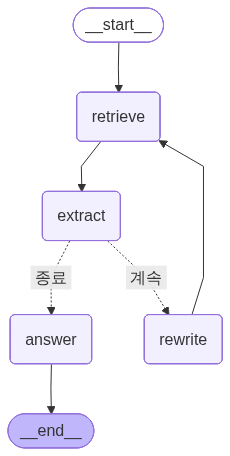


✅ [완료] Guideline Agent 그래프 구조 시각화 완료 ✅

📊 Guideline Workflow 구조:

START → retrieve → extract
 ├─(계속)→ rewrite → retrieve
 └─(종료)→ answer → END



In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal, List, Dict
from pprint import pprint
import datetime
import re


# ======================================
# 1️⃣ GuidelineRagState 정의
# ======================================
class GuidelineRagState(QAState):
    """
    완성편입 전용 Guideline 검색용 상태 구조
    QAState를 확장하여 추가 필드 포함
    """
    rewritten_query: str              # 재작성된 검색 쿼리
    related_info: List[Dict]          # 추출된 정보 리스트
    node_answer: str                  # 최종 노드 답변
    num_generations: int              # 루프 반복 횟수
    sources: List[str]                # 최종 출처 리스트


# ======================================
# 2️⃣ 공통 로그 함수
# ======================================
def log(message: str, state: Dict = None):
    """시간 + 단계 + 상태 키 표시용 공용 로그 함수"""
    print(f"\n[{datetime.datetime.now().strftime('%H:%M:%S')}] {message}")
    if state:
        keys = ', '.join(list(state.keys()))
        print(f"  ↳ 현재 state keys: [{keys}]")


# ======================================
# 3️⃣ Guideline 문서 검색 단계
# ======================================
def retrieve_guideline_docs(state: GuidelineRagState) -> GuidelineRagState:
    """
    GuidelineDB의 [question] 컬럼을 기준으로 Embedding 검색 수행
    """
    log("==== [1단계] retrieve_guideline_docs (question을 기준으로 GuidelineDB에서 검색 수행) 시작 ====", state)

    query = state.get("rewritten_query", state["question"])
    print(f"📢 검색 쿼리 입력값: {query}")
    print("📚 검색 기준 필드: GuidelineDB의 [question] 컬럼 (임베딩 매칭)")

    docs = guideline_search.invoke(query)
    print(f"📄 검색 결과 문서 수: {len(docs)}")

    if len(docs) > 0:
        print("🧾 Top 1 검색 결과 미리보기:")
        preview_q = docs[0].page_content.split("\n")[0][:100]
        src_detail = docs[0].metadata.get("source_detail", "출처 미기재")
        print(f"   ▶ Q: {preview_q}")
        print(f"   ▶ 출처: {src_detail}")
    else:
        print("❗ 검색 결과가 없습니다. 쿼리를 재작성하거나 DB를 확인하세요.")

    # 출처 목록을 sources 필드에 저장
    sources = [
        f"{doc.metadata.get('source_name', 'GuidelineDB')} ({doc.metadata.get('source_detail', '출처 미기재')})"
        for doc in docs
    ]

    return {"search_results": docs, "sources": sources}


# ======================================
# 4️⃣ 문서 정보 추출 및 평가 단계
# ======================================
def extract_guideline_info(state: GuidelineRagState) -> GuidelineRagState:
    log("==== [2단계] extract_guideline_info (문서에서 관련 핵심정보 추출 및 평가) 시작 ====", state)
    extracted_list = []

    try:
        for i, doc in enumerate(state["search_results"]):
            print(f"\n🧾 {i+1}번째 문서 분석 중...")
            src_detail = doc.metadata.get("source_detail", "출처 미기재")
            print(f"   ▶ 출처: {src_detail}")

            doc_q = doc.page_content
            doc_a = doc.metadata.get("answer", "")
            print(f"   Q: {doc_q[:100]}")
            print(f"   A: {doc_a[:100]}")

            prompt = ChatPromptTemplate.from_messages([
                ("system", """당신은 대학 편입 모집요강 전문가입니다.
                아래 Q/A 문서에서 학생 질문과 관련된 주요 사실을 3~5개 정도 추출하세요. 
                각 항목은 다음과 같은 형식을 따릅니다:

                1. [추출된 정보 요약]
                - 관련성 점수: 0~1 사이 숫자
                - 충실성 점수: 0~1 사이 숫자
                """),
                ("human", "질문: {question}\n\n[문서]\nQ: {q}\nA: {a}")
            ])
            formatted = prompt.format(question=state["question"], q=doc_q, a=doc_a)
            result = llm.invoke(formatted)

            if not result or not result.content.strip():
                print("⚠️ LLM 결과 없음 → 문서 스킵")
                continue

            # --- 점수 추출 ---
            text = result.content.strip()
            relevance_scores = [float(x) for x in re.findall(r"관련성\s*점수\s*[:：]?\s*([0-9]*\.?[0-9]+)", text)]
            faithfulness_scores = [float(x) for x in re.findall(r"충실성\s*점수\s*[:：]?\s*([0-9]*\.?[0-9]+)", text)]

            avg_rel = sum(relevance_scores)/len(relevance_scores) if relevance_scores else 0
            avg_fai = sum(faithfulness_scores)/len(faithfulness_scores) if faithfulness_scores else 0

            print(f"   📊 평균 관련성: {avg_rel:.2f}, 평균 충실성: {avg_fai:.2f}")

            # --- 점수 기준 필터링 ---
            if avg_rel < 0.7 or avg_fai < 0.7:
                print("🚫 점수가 낮아 제외됨 (기준: 0.7 이상)")
                continue

            extracted_list.append({
                "content": text,
                "source": src_detail,
                "avg_relevance": avg_rel,
                "avg_faithfulness": avg_fai
            })

        if len(extracted_list) == 0:
            print("❗ 관련 정보가 추출되지 않았거나 점수 기준 미달입니다.")

        log("✅ 정보 추출 및 필터링 완료", {"추출된 정보 개수": len(extracted_list)})
        return {
            "related_info": extracted_list,
            "num_generations": state.get("num_generations", 0) + 1
        }

    except Exception as e:
        print(f"❌ [오류] extract_guideline_info 실패: {e}")
        return {"related_info": [], "num_generations": 0}


# ======================================
# 5️⃣ 검색 쿼리 재작성 단계
# ======================================
def rewrite_guideline_query(state: GuidelineRagState) -> GuidelineRagState:
    """
    정보 부족 시, LLM을 통해 검색 쿼리 재작성 수행
    """
    log("==== [3단계] rewrite_guideline_query (검색 쿼리 재작성) 시작 ====", state)
    info_text = "\n".join([i["content"] for i in state["related_info"]])

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 대학 편입 전문 상담가입니다.
        아래 질문과 추출된 정보를 참고하여 더 구체적이고 정확한 검색 쿼리를 다시 작성하세요.
        - 핵심 키워드: 학교명, 학과명, 지원유형(일반/학사), 과목, 일정
        - 한 줄로 간결하게 작성
        """),
        ("human", "질문: {question}\n\n추출된 정보:\n{info}")
    ])

    rewritten = llm.invoke(rewrite_prompt.format(question=state["question"], info=info_text))
    new_query = rewritten.content.strip()

    print(f"💡 재작성된 쿼리: {new_query}")
    return {"rewritten_query": new_query}


# ======================================
# 6️⃣ 최종 답변 생성 단계
# ======================================
def generate_guideline_answer(state: GuidelineRagState) -> GuidelineRagState:
    """
    모든 추출 정보를 종합해 학생 질문에 대한 최종 답변 생성
    """
    log("==== [4단계] generate_guideline_answer (최종 답변 생성) 시작 ====", state)

    # 정보 병합 및 출처 표시
    info_text = "\n".join([f"- {i['content']} (출처: {i['source']})" for i in state["related_info"]])
    source_summary = "\n".join([f"- {s}" for s in state.get("sources", [])])

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 대학 편입 모집요강 전문 상담가입니다.
        학생의 질문과 관련 정보를 종합하여 답변을 작성하세요.
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다.
        출력 구조:
        1. 핵심 요약
        2. 세부 내용
        3. 참고 출처
        """),
        ("human", "질문: {question}\n\n관련 정보:\n{info}\n\n참고 출처:\n{src}")
    ])

    answer = llm.invoke(answer_prompt.format(
        question=state["question"],
        info=info_text,
        src=source_summary
    ))

    print("🗒️ 생성된 답변 미리보기:\n", answer.content[:300], "...")
    log("✅ 최종 답변 생성 완료")
    return {"node_answer": answer.content, "sources": state.get("sources", [])}


# ======================================
# 7️⃣ 판단 단계
# ======================================
def should_continue_guideline(state: GuidelineRagState) -> Literal["계속", "종료"]:
    """
    정보 충분 여부에 따라 그래프 진행 방향 결정
    """
    log("==== [판단단계] should_continue_guideline (정보 충족 여부 판단) ====", state)
    print("📊 현재 related_info 개수:", len(state.get("related_info", [])))
    print("🔢 현재 반복 횟수:", state.get("num_generations", 0))

    gen = state.get("num_generations", 0)
    info_count = len(state.get("related_info", []))

    if gen >= 2:
        print("🔁 반복 횟수 초과 → 종료")
        return "종료"

    if info_count > 0:
        print(f"📈 충분한 정보 확보 ({info_count}개) → 종료")
        return "종료"

    print("🔄 정보 부족 → 쿼리 재작성 후 재검색")
    return "계속"


# ======================================
# 8️⃣ 그래프 구성 및 컴파일
# ======================================
log("🚀 [초기화] LangGraph Guideline Search Workflow 구성 시작")

guideline_graph = StateGraph(GuidelineRagState)

guideline_graph.add_node("retrieve", retrieve_guideline_docs)
guideline_graph.add_node("extract", extract_guideline_info)
guideline_graph.add_node("rewrite", rewrite_guideline_query)
guideline_graph.add_node("answer", generate_guideline_answer)

guideline_graph.add_edge(START, "retrieve")
guideline_graph.add_edge("retrieve", "extract")

guideline_graph.add_conditional_edges(
    "extract",
    should_continue_guideline,
    {"계속": "rewrite", "종료": "answer"}
)

guideline_graph.add_edge("rewrite", "retrieve")
guideline_graph.add_edge("answer", END)

guideline_agent = guideline_graph.compile()
log("✅ [완료] Guideline Agent 컴파일 완료")


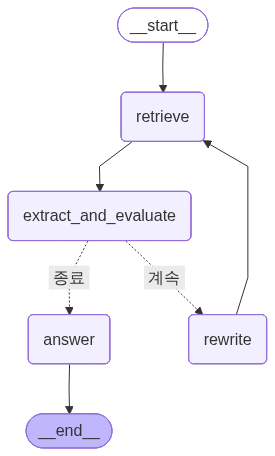


✅ [완료] Guideline Agent 그래프 구조 시각화 완료 ✅


In [30]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# ======================================
# 🎯 Guideline Search Graph 구성
# ======================================

# 그래프 생성
workflow = StateGraph(GuidelineRagState)

# 노드 추가
workflow.add_node("retrieve", retrieve_guideline_docs)         # 1단계: DB 검색
workflow.add_node("extract_and_evaluate", extract_guideline_info)           # 2단계: 정보 추출 및 평가
workflow.add_node("rewrite", rewrite_guideline_query)          # 3단계: 쿼리 재작성
workflow.add_node("answer", generate_guideline_answer)         # 4단계: 최종 답변 생성

# 엣지 추가
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "extract_and_evaluate")

# 조건부 엣지 추가
workflow.add_conditional_edges(
    "extract_and_evaluate",
    should_continue_guideline,  # 판단 로직
    {
        "계속": "rewrite",      # 정보 부족 시 → 쿼리 재작성으로 이동
        "종료": "answer"        # 충분한 정보 확보 시 → 최종 답변 생성으로 이동
    }
)

# 재작성 후 다시 검색으로
workflow.add_edge("rewrite", "retrieve")

# 최종 답변 후 종료
workflow.add_edge("answer", END)

# 그래프 컴파일
guideline_agent = workflow.compile()

# ======================================
# 🧭 그래프 시각화
# ======================================
display(Image(guideline_agent.get_graph().draw_mermaid_png()))

print("\n✅ [완료] Guideline Agent 그래프 구조 시각화 완료 ✅")


In [26]:
# 테스트 입력 예시
inputs = {
    "question": "중앙대학교 이과 편입은 어떤 과목을 준비해야 하나요?",
    "student_profile": {"target_university": "중앙대학교", "track": "이과"}
}

# 스트리밍 실행 (각 노드별 진행 로그 확인)
print("\n===== 🚀 Guideline Graph 테스트 실행 =====\n")
for output in guideline_agent.stream(inputs):
    for key, value in output.items():
        print(f"\n🧩 [노드: {key}] 실행 결과:")
        pprint(value)
    print("\n------------------------------------\n")

print("\n✅ 최종 답변:")
print(value["node_answer"])



===== 🚀 Guideline Graph 테스트 실행 =====


[20:25:07] ==== [1단계] retrieve_guideline_docs (question을 기준으로 GuidelineDB에서 검색 수행) 시작 ====
  ↳ 현재 state keys: [question, student_profile]
📢 검색 쿼리 입력값: 중앙대학교 이과 편입은 어떤 과목을 준비해야 하나요?
📚 검색 기준 필드: GuidelineDB의 [question] 컬럼 (임베딩 매칭)

🔍 [GuidelineDB Search] 쿼리: 중앙대학교 이과 편입은 어떤 과목을 준비해야 하나요?
📄 검색 결과 문서 수: 2
   ▶ [1] 중앙대학교 이과 편입은 어떤 과목을 준비해야 하나요?... (출처: cau2025-page7)
   ▶ [2] 편입 공부 시작은 어떤 과목부터 해야 하나요?... (출처: line834)
✅ Guideline 검색 결과 포맷 완료.
📄 검색 결과 문서 수: 2
🧾 Top 1 검색 결과 미리보기:
   ▶ Q: Q: 중앙대학교 이과 편입은 어떤 과목을 준비해야 하나요?
   ▶ 출처: cau2025-page7

🧩 [노드: retrieve] 실행 결과:
{'search_results': [Document(metadata={'source': 'guidelineDB', 'source_name': 'GuidelineDB', 'source_detail': 'cau2025-page7'}, page_content='Q: 중앙대학교 이과 편입은 어떤 과목을 준비해야 하나요?\nA: 중앙대학교 이과편입은 수학 시험만 응시합니다'),
                    Document(metadata={'source': 'guidelineDB', 'source_name': 'GuidelineDB', 'source_detail': 'line834'}, page_content='Q: 편입 공부 시작은 어떤 과목부터 해야 하나요?\nA: 수학과 영어를 병행하되, 기